In [1]:
import numpy as np

X_train = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/training.npy')
y_train = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/training_labels.npy')
X_test = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/test.npy')
y_test = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/test_labels.npy')
embedding_matrix = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/embedding_matrix.npy')

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Bidirectional, Dense, Embedding, LSTM, Dropout, Conv1D, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping

vocab_size = 52145

embedding = Embedding(vocab_size,
                      output_dim=int(3e2),
                      weights=[embedding_matrix],
                      trainable=True)

model = Sequential()
model.add(embedding)
model.add(LSTM(256, return_sequences=True, input_shape=(X_train.shape[1],1)))#
model.add(Dropout(0.25))
model.add(LSTM(256))
# model.add(Dropout(0.3))
# model.add(Dense(32))
# model.add(Dropout(0.3))
# model.add(Dense(16))
model.add(Dropout(0.25))
model.add(Dense(128))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 300)         15643500  
                                                                 
 lstm (LSTM)                 (None, None, 256)         570368    
                                                                 
 dropout (Dropout)           (None, None, 256)         0         
                                                                 
 lstm_1 (LSTM)               (None, 256)               525312    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense (Dense)               (None, 128)               32896     
                                                                 
 dense_1 (Dense)             (None, 1)                 1

In [3]:
callbacks = EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5)
history = model.fit(X_train, y_train,
                    batch_size=1024,
                    epochs=100,
                    verbose=1,
                    validation_split=0.1)


Epoch 1/100
22/22 [==============================] - 24s 768ms/step - loss: 0.6849 - accuracy: 0.5514 - val_loss: 0.7934 - val_accuracy: 0.0992
Epoch 2/100
22/22 [==============================] - 16s 718ms/step - loss: 0.6707 - accuracy: 0.5796 - val_loss: 0.7878 - val_accuracy: 0.1528
Epoch 3/100
22/22 [==============================] - 16s 733ms/step - loss: 0.6583 - accuracy: 0.6060 - val_loss: 0.7784 - val_accuracy: 0.2320
Epoch 4/100
22/22 [==============================] - 16s 732ms/step - loss: 0.6438 - accuracy: 0.6353 - val_loss: 0.7562 - val_accuracy: 0.3532
Epoch 5/100
22/22 [==============================] - 16s 741ms/step - loss: 0.6271 - accuracy: 0.6671 - val_loss: 0.7330 - val_accuracy: 0.4520
Epoch 6/100
22/22 [==============================] - 17s 756ms/step - loss: 0.6054 - accuracy: 0.6964 - val_loss: 0.6934 - val_accuracy: 0.5616
Epoch 7/100
22/22 [==============================] - 17s 761ms/step - loss: 0.5783 - accuracy: 0.7184 - val_loss: 0.6512 - val_accuracy:

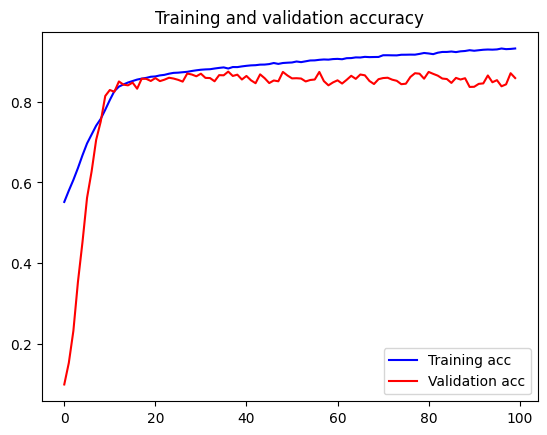

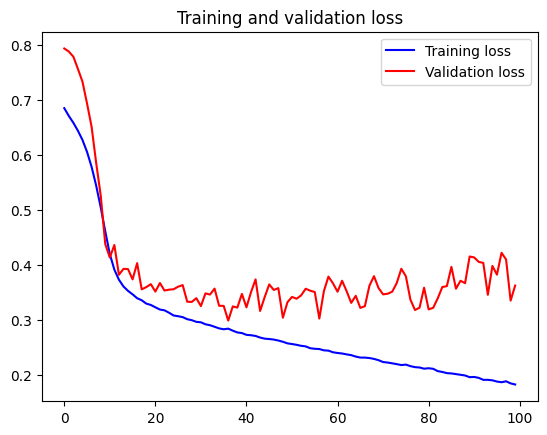

In [4]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [5]:
score = model.evaluate(X_test, y_test, batch_size=1024)
print()
print("ACCURACY:",score[1])
print("LOSS:",score[0])

25/25 [==============================] - 6s 236ms/step - loss: 0.3144 - accuracy: 0.8773

ACCURACY: 0.877315104007721
LOSS: 0.3143916428089142
